In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
import torch.nn.functional as F

import cv2
import torch

from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import AutoImageProcessor, DPTForDepthEstimation
from PIL import Image

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

In [2]:
label_path = r'6 dataset (160-2560, step=140)\masks (3 classes) (new)'
srez_path = r'6 dataset (160-2560, step=140)\initial images (new)'

In [3]:
label = cv2.imread(label_path + r"\output_00160.tif")[:, :, 0]
srez = cv2.imread(srez_path + r"\00160.png")[:, :, 0]

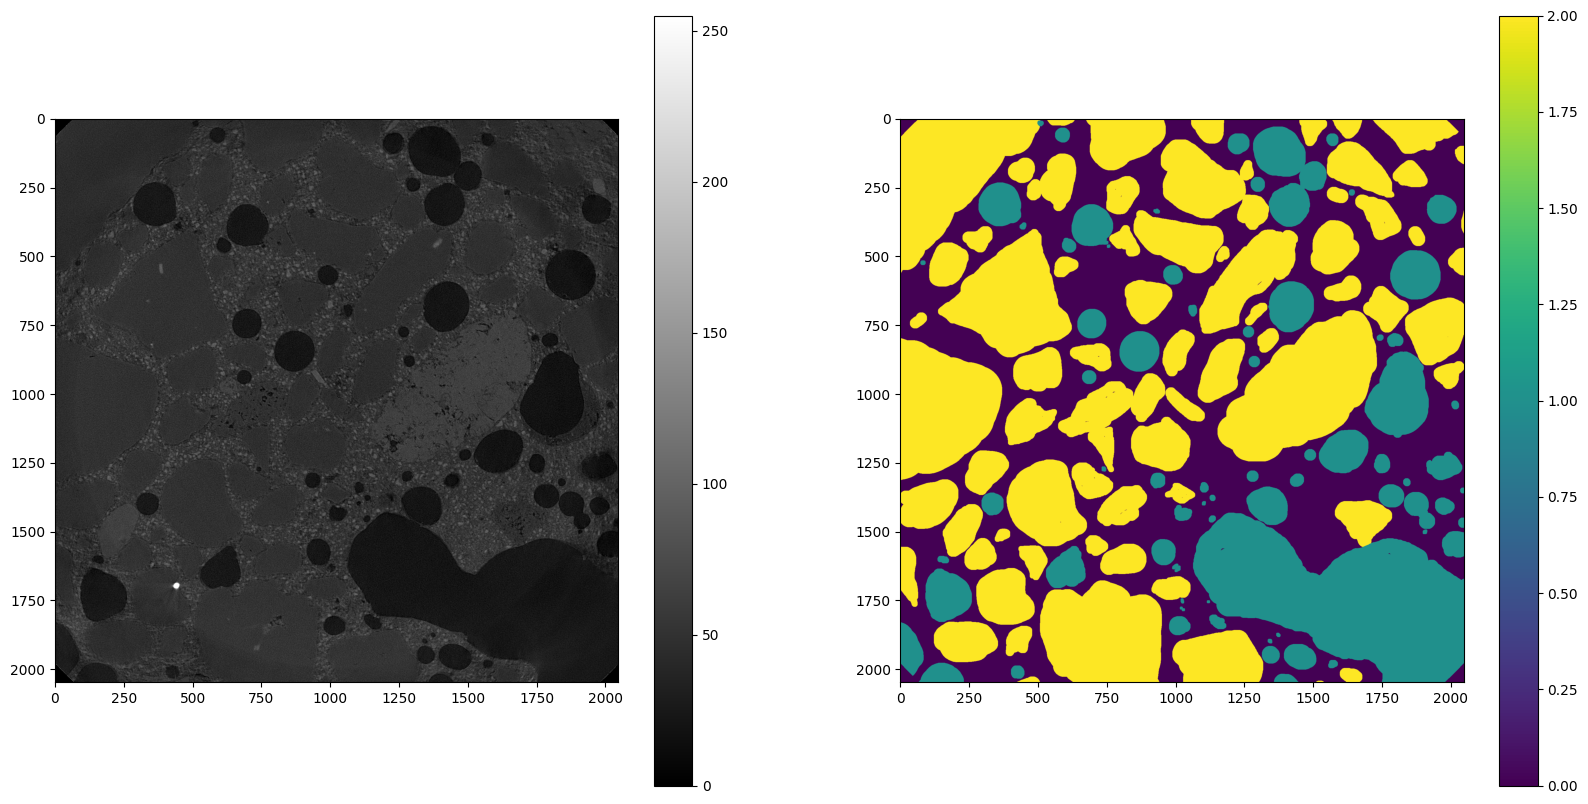

In [4]:
c_x = srez.shape[0] // 2
c_y = srez.shape[1] // 2
w = label.shape[0] // 2
h = label.shape[1] // 2
crop_srez = srez[(c_x-w):(c_x+w), (c_y-h):(c_y+h)]
plt.figure(figsize=(20,10))
plt.subplot(121)
im = plt.imshow(crop_srez, cmap = "gray")
plt.colorbar(im) 
plt.subplot(122)
im = plt.imshow(label)
plt.colorbar(im) 

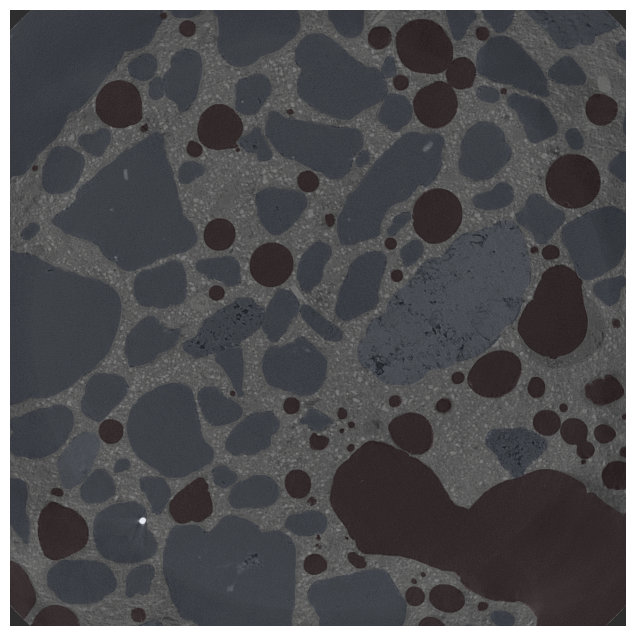

In [5]:
import matplotlib.pyplot as plt
import numpy as np

alpha = 0.1

plt.figure(figsize=(8,8))
plt.imshow(crop_srez, cmap="gray")

plt.imshow(label == 1, cmap="Reds", alpha=alpha)
plt.imshow(label == 2, cmap="Blues", alpha=alpha)

plt.axis("off")
plt.show()

In [6]:
#сбор статистики
np.unique(label)

array([0, 1, 2], dtype=uint8)

In [7]:
crop_srez[label == 0].mean()
pore_values = crop_srez[label == 1]
rock_values = crop_srez[((label == 0) | (label == 2))]

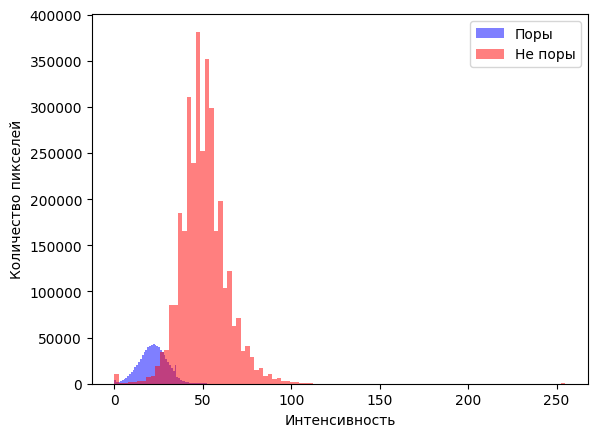

In [8]:
plt.hist(pore_values, bins=100, alpha=0.5, label='Поры', color='blue')
plt.hist(rock_values, bins=100, alpha=0.5, label='Не поры', color='red')
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.legend()
plt.show()

In [9]:
def multiclass_IOU(pred: torch.Tensor, target: torch.Tensor, num_classes: int, eps: float = 1e-6):
    """
    Векторизованная версия IoU для мультиклассовой сегментации.
    
    Args:
        pred (torch.Tensor): предсказания модели [B, C, H, W]
        target (torch.Tensor): истинные метки [B, H, W]
        num_classes (int): количество классов
        eps (float): маленькое число для избежания деления на ноль

    Returns:
        iou_per_class (torch.Tensor): тензор размера [num_classes] с IoU для каждого класса
    """
    # Получаем предсказанные метки
    pred_labels = torch.argmax(pred, dim=1)  # [B, H, W]

    # one-hot кодируем pred и target
    pred_onehot = torch.nn.functional.one_hot(pred_labels, num_classes=num_classes)  # [B, H, W, C]
    target_onehot = torch.nn.functional.one_hot(target, num_classes=num_classes)     # [B, H, W, C]

    # Переставим оси, чтобы было [B, C, H, W]
    pred_onehot = pred_onehot.permute(0, 3, 1, 2).float()
    target_onehot = target_onehot.permute(0, 3, 1, 2).float()

    # Пересечение и объединение для каждого класса
    intersection = (pred_onehot * target_onehot).sum(dim=(0, 2, 3))
    union = (pred_onehot + target_onehot - pred_onehot * target_onehot).sum(dim=(0, 2, 3))

    iou = (intersection + eps) / (union + eps)
    return iou

In [10]:
# files = list(zip(os.listdir(label_path), os.listdir(srez_path)))
# n = len(files)

# plt.figure(figsize=(20, 5 * n))

# for i, (l_p, s_p) in enumerate(files):
#     label = cv2.imread(label_path + '/' + l_p)[:, :, 0]
#     srez = cv2.imread(srez_path + '/' + s_p)[:, :, 0]

#     c_x = srez.shape[0] // 2
#     c_y = srez.shape[1] // 2
#     w = label.shape[0] // 2
#     h = label.shape[1] // 2
#     crop_srez = srez[(c_x-w):(c_x+w), (c_y-h):(c_y+h)]

#     plt.subplot(n, 2, 2*i + 1)
#     im = plt.imshow(crop_srez, cmap="gray")
#     plt.colorbar(im)

#     plt.subplot(n, 2, 2*i + 2)
#     im = plt.imshow(label)
#     plt.colorbar(im)

# plt.tight_layout()
# plt.show()

In [11]:
files = list(zip(os.listdir(label_path), os.listdir(srez_path)))
n = len(files)

num_classes = 2
image_list = []
target_list = []
for i, (l_p, s_p) in enumerate(files):
    label = cv2.imread(label_path + '/' + l_p)[:, :, 0]
    srez = cv2.imread(srez_path + '/' + s_p)[:, :, 0].astype(float) / 255

    c_x = srez.shape[0] // 2
    c_y = srez.shape[1] // 2
    w = label.shape[0] // 2
    h = label.shape[1] // 2
    crop_srez = srez[(c_x-w):(c_x+w), (c_y-h):(c_y+h)]
    
    label[label == 2] = 0

    image_list.append(np.expand_dims(crop_srez, 0))
    target_list.append(label)


In [12]:
class_pixels = [0] * num_classes
for target in target_list:
    for i in range(num_classes):
        class_pixels[i] += (target == i).sum()
class_weights = torch.zeros([num_classes])
for i in range(num_classes):
    class_weights[i] = 1 / (class_pixels[i] / sum(class_pixels))
class_weights /= class_weights.sum()
class_weights

tensor([0.1143, 0.8857])

In [13]:
class CoreDataset(torch.utils.data.Dataset):
    def __init__(self, labels, srez_list, transform=None):
        """
        labels: list of numpy arrays (H,W) или (H,W,1)
        srez_list: list of numpy arrays (H,W) или (H,W,1)
        transform: albumentations.Compose или любой кастомный трансформ
        """
        assert len(labels) == len(srez_list), "Labels and srez lists must have the same length"
        
        self.labels = labels
        self.srez_list = srez_list
        self.transform = transform
        self.processor = AutoImageProcessor.from_pretrained("facebook/dpt-dinov2-base-nyu")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label = self.labels[idx].astype("float32")
        srez = self.srez_list[idx].astype(np.long)

        c_x = srez.shape[0] // 2
        c_y = srez.shape[1] // 2
        w = label.shape[0] // 2
        h = label.shape[1] // 2

        crop_srez = srez[(c_x - w):(c_x + w), (c_y - h):(c_y + h)]

    
        if self.transform:
            transformed = self.transform(image=crop_srez, target=label)
            crop_srez = transformed['image']
            label = transformed['target']

        crop_srez = np.expand_dims(crop_srez, axis=0)

        crop_srez = self.processor(crop_srez)['pixel_values'][0]

        return {
            "image": crop_srez,  
            "target": label       
        }

In [14]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomRotate90(p=0.5),

    A.Affine(
        scale=(1.5, 3.0),
        translate_percent=0,
        rotate=0,
        p=0.2
    ),

    # A.GaussianBlur(p = 0.25, sigma_limit = [0.5, 1]),
    A.GaussNoise(p = 0.3, std_range=(0.02, 0.05)),
    # A.Downscale(scale_range=[0.5, 0.75], p = 0.25),

    #A.RandomResizedCrop(size = [256, 256], scale = [0.8, 1.0]),

    A.RandomBrightnessContrast(p = 1),
    # my_utils.AddBrChannel(1.4, 0.4),
    # my_utils.AddBrChannel(0.6, -0.4),

    A.Normalize(),
], additional_targets={'target': 'mask'})

val_transform = A.Compose([
    A.Normalize(),
], additional_targets={'target': 'mask'})

In [15]:
model = DPTForDepthEstimation.from_pretrained("facebook/dpt-dinov2-base-nyu")

model.head.head[4] = torch.nn.Conv2d(32, num_classes, kernel_size=(1, 1), stride=(1, 1))
model.head.head[5] = torch.nn.Identity()
#model.head.head[5] = torch.nn.Sigmoid()

# for param in model.parameters():
#     param.requires_grad = False
# for param in model.head.parameters():
#     param.requires_grad = True



total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]

Total params: 111,954,082
Trainable params: 111,954,082


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 4
num_epochs = 100
learning_rate = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         
    factor=0.2,    
    patience=3,            
    min_lr=1e-6,
    threshold = 1e-3          
)

In [19]:
def crop_4(image: np.ndarray, crop_size: int = 560):
    """
    Делит одно изображение (NumPy array) на 4 кропа заданного размера.

    Args:
        image (np.ndarray): массив [H, W] или [H, W, C]
        crop_size (int): размер кропа

    Returns:
        patches (list of np.ndarray): список из 4 кропов
    """
    if image.ndim == 2:
        H, W = image.shape
        C = None
    elif image.ndim == 3:
        C, H, W = image.shape
    else:
        raise ValueError("image должен быть [H, W] или [H, W, C]")

    if H < crop_size or W < crop_size:
        raise ValueError(f"Изображение слишком маленькое ({H}x{W}) для кропа {crop_size}x{crop_size}")

    # верхний левый
    patch1 = image[0:crop_size, 0:crop_size] if C is None else image[:, 0:crop_size, 0:crop_size]
    # верхний правый
    patch2 = image[0:crop_size, W-crop_size:W] if C is None else image[:, 0:crop_size, W-crop_size:W]
    # нижний левый
    patch3 = image[H-crop_size:H, 0:crop_size] if C is None else image[:, H-crop_size:H, 0:crop_size]
    # нижний правый
    patch4 = image[H-crop_size:H, W-crop_size:W] if C is None else image[:, H-crop_size:H, W-crop_size:W]

    return [patch1, patch2, patch3, patch4]

In [20]:
train_target = [crop_4(p) for p in target_list[:32]] 
train_image = [crop_4(p) for p in image_list[:32]] 

train_target = [item for sublist in train_target for item in sublist]
train_image = [item for sublist in train_image for item in sublist]

train_dataset = CoreDataset(train_target, train_image, transform)

val_target = [crop_4(p) for p in target_list[32:]] 
val_image = [crop_4(p) for p in image_list[32:]] 

val_target = [item for sublist in val_target for item in sublist]
val_image = [item for sublist in val_image for item in sublist]

validation_dataset = CoreDataset(val_target, val_image, val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [21]:
model.to(device)

log_dir = f"runs/depth_{datetime.now().strftime('%d_%m_%H_%M')}"
writer = SummaryWriter(log_dir=log_dir)


for epoch in range(num_epochs):
    running_loss = 0.0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        images = batch["image"].to(device)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]
        
        targets = targets.unsqueeze(1)
        targets = F.interpolate(targets, [640, 640], mode = 'nearest-exact')
        targets = targets.squeeze(1)
        
        outputs = model(images)
        pred = outputs.predicted_depth

        loss = loss_fn(pred, targets.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {running_loss/len(train_loader):.4f} lr = {scheduler.get_last_lr()}")
    writer.add_scalar("Loss/train", running_loss/len(train_loader), epoch)
    

    running_loss = 0.0
    iou_metric = 0
    with torch.no_grad():
            for idx, batch in tqdm(enumerate(validation_loader)):
                images = batch["image"].to(device)   # [B, C, H, W]
                targets = batch["target"].to(device) # [B, H, W]

                targets = targets.unsqueeze(1)
                targets = F.interpolate(targets, [640, 640], mode = 'nearest-exact')
                targets = targets.squeeze(1)

                outputs = model(images)
                pred = outputs.predicted_depth
                loss = loss_fn(pred, targets.long())
                running_loss += loss.item()
                iou_metric += multiclass_IOU(pred, targets.long(), num_classes)

                if idx == 0:  
                    B = images.size(0)
                    val_fig, axes = plt.subplots(B, 3, figsize=(12, 4 * B))

                    for j in range(B):
                        img = images[j].detach().cpu().permute(1, 2, 0).numpy()
                        gt = targets[j].cpu().numpy()
                        pr = pred[j].detach().cpu()


                        axes[j, 0].imshow(img)
                        axes[j, 0].set_title("Image")
                        axes[j, 0].axis('off')

                        axes[j, 1].imshow(gt)
                        axes[j, 1].set_title("Target")
                        axes[j, 1].axis('off')

                        axes[j, 2].imshow(pr)
                        axes[j, 2].set_title("Prediction")
                        axes[j, 2].axis('off')

                    plt.tight_layout()
                    writer.add_figure("Val/Predictions", val_fig, epoch)
                    plt.close(val_fig)
    print(f"Epoch {epoch+1}/{num_epochs} - Validation Loss: {running_loss/len(validation_loader):.4f}")
    writer.add_scalar("Loss/val", running_loss/len(validation_loader), epoch)
    print('Validation IoU', [f"{v.item():.2f}" for v in (iou_metric / len(validation_loader)).cpu()])
    scheduler.step(running_loss/len(validation_loader))

  0%|          | 0/32 [00:00<?, ?it/s]


ValueError: Height and Width of image, mask or masks should be equal. You can disable shapes check by setting a parameter is_check_shapes=False of Compose class (do it only if you are sure about your data consistency).

In [22]:
train_image

[array([[[0.        , 0.        , 0.        , ..., 0.14509804,
          0.16078431, 0.16862745],
         [0.        , 0.        , 0.        , ..., 0.18823529,
          0.17647059, 0.14117647],
         [0.        , 0.        , 0.        , ..., 0.20784314,
          0.21568627, 0.18039216],
         ...,
         [0.11372549, 0.10980392, 0.09019608, ..., 0.17254902,
          0.18039216, 0.14509804],
         [0.14509804, 0.09019608, 0.12941176, ..., 0.16078431,
          0.1254902 , 0.17647059],
         [0.16470588, 0.11764706, 0.16078431, ..., 0.19607843,
          0.19215686, 0.21960784]]], shape=(1, 560, 560)),
 array([[[0.17647059, 0.17647059, 0.14509804, ..., 0.        ,
          0.        , 0.        ],
         [0.14509804, 0.18039216, 0.15294118, ..., 0.        ,
          0.        , 0.        ],
         [0.12941176, 0.14509804, 0.1372549 , ..., 0.        ,
          0.        , 0.        ],
         ...,
         [0.28235294, 0.2       , 0.16078431, ..., 0.18039216,
   